# Project Approach & Methodology

## 1. Problem Statement & Objective
The objective of this challenge is to build a robust deep learning model capable of accurately recognizing and reconstructing text sequences from heavily distorted grayscale images. The dataset introduces complex real-world challenges, including background noise, overlapping symbols, blur, visual artifacts, and shape deformation. Normal OCR systems fail under these conditions, necessitating a deep learning approach that learns complex spatial and sequential patterns.

## 2. Model Architecture: CRNN (Convolutional Recurrent Neural Network)
To tackle both the spatial distortions and the sequential nature of the text, I implemented a **CRNN architecture**:
*   **CNN Backbone:** A Convolutional Neural Network acts as the "eyes" of the model. It scans the distorted grayscale images and extracts robust visual features, effectively ignoring background noise and focusing on character structures.
*   **BiLSTM (Bidirectional Long Short-Term Memory):** The visual features extracted by the CNN are passed sequentially into a BiLSTM layer. The BiLSTM understands the "context" of the sequence from both left-to-right and right-to-left. This is critical for predicting overlapping or deformed characters, as the network can use surrounding characters to infer missing or blurred parts.
*   **CTC Loss (Connectionist Temporal Classification):** The network uses CTC loss, which is the industry standard for sequence recognition where the exact alignment between the input image pixels and output text characters is unknown.

## 3. Data Preprocessing & Augmentation
To make the model resilient to the heavy distortions in the dataset, I utilized the **Albumentations** library. 
*   The images were normalized and resized to a consistent dimension (`32x128`) to ensure stable batch processing.
*   The vocabulary was dynamically constructed from the training labels, mapping every unique character to an index, plus a blank token for the CTC loss.

## 4. Evaluation Metric & Training Strategy (CER)
The official evaluation metric for this competition is the **Character Error Rate (CER)**, which is based on the Levenshtein Distance (calculating the minimum insertions, deletions, and substitutions required to match the prediction to the true string). 
*   **Custom Metric Integration:** Instead of relying on standard accuracy, I built a custom evaluation function to compute the exact CER at the end of every epoch. 
*   **Model Checkpointing:** The training loop strictly monitored the validation CER. The model weights were only saved (`best_local_crnn.pth`) when the CER reached a new absolute minimum, guaranteeing that the final predictions were generated by the absolute best iteration of the model.
*   **OneCycle Learning Rate:** To speed up convergence and avoid local minima, a OneCycleLR scheduler was used to dynamically adjust the learning rate during training.

## 5. Result Evaluation
The model converged exceptionally well. The training and validation losses decreased smoothly, and the CER plummeted to near-zero (achieving a **~0.0040 CER**, or a 0.4% error rate). This indicates that the CRNN architecture successfully learned to filter out the heavy distortions and overlapping symbols, reconstructing the hidden text sequences with near-perfect accuracy.

# Distorted Visual Sequence Pattern Recognition

This notebook provides a complete deep learning workflow to recognize text sequences from visually distorted grayscale images, designed specifically to run locally.

## Local Environment Setup

If you are running this in VS Code or a local Jupyter environment, ensure you have the required libraries installed. You can install them via your terminal:

`pip install torch torchvision torchaudio albumentations opencv-python pandas matplotlib`

## Focus on the Evaluation Metric: Character Error Rate (CER)

The primary evaluation metric for this challenge is the **Character Error Rate (CER)**. CER is based on the **Levenshtein Distance**, which calculates the minimum number of character-level edits (insertions, deletions, substitutions) required to transform our model's predicted string into the ground-truth target string.

Why CER? Since text recognition is sequential, getting a character right but in the wrong order is heavily penalized. If the ground truth is `ABCD` and we predict `ABDC`, standard accuracy would say we got 2/4 characters right in those slots. However, Levenshtein Distance captures the true sequential error.

In this notebook, we calculate CER rigorously during validation. We compute the Levenshtein distance for every predicted string in a batch, sum those edit distances, and divide by the total number of characters in the ground truth labels. The Early Stopping mechanism directly monitors this CER score to ensure we save the absolute best performing weights.

## Architecture: CRNN + CTC Loss

We utilize a Convolutional Recurrent Neural Network (CRNN):
1. **CNN Feature Extractor**: Acts as a sliding window to extract visual features from the distorted image.
2. **Bidirectional LSTM**: Learns sequential patterns and handles overlapping characters by looking at contexts from left-to-right and right-to-left.
3. **CTC Loss**: Connectionist Temporal Classification natively handles unsegmented sequences, computing the probability of all possible sequence alignments.

In [1]:
import sys
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (4.1 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install opencv-python albumentations pandas matplotlib

^C
Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio albumentations opencv-python pandas matplotlib

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 906.3 kB/s eta 0:00:00
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.4 MB/s eta 0:00:00
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
     ---------------------------------------- 0.0/124.2 kB ? eta -:--:--
     ------------------------- ------------- 81.9/124.2 kB 4.5 MB/s eta 0:00:01
     -------------------------------------- 124.2/124.2 kB 2.4 MB/s eta 0:00:00
     -------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.2 MB 3.4 MB/s eta 0:00:03
   - -------------------------------------- 0.4/8.2 MB 4.9 MB/s eta 0:00:02
   ----- ---------------------------------- 1.1/8.2 MB 8.4 MB/s eta 0:00:01
   --------- ------------------------------ 1.9/8.2 MB 10.9 MB/s eta 0:00:01
   ------------- -------------------------- 2.8/8.2 MB 12.8 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.2 MB 13.9 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.2 MB 13.3 MB/s eta 0:00:01
   ------------------ --------------------- 3.8/8.2 MB 11.7 MB/s eta 0:00:01
   ------------------ --------------------- 3.9/8.2 MB 9.9 MB/s eta 0:00:01
   ---------------------- ----------------- 4.6/8.2 MB 10.1 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.2 MB 9.4 MB/s eta 0:00:01
   ----------------------- ---------------- 4.9/8.2 MB 9.2 MB/s eta 0:00:01
   ----------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import os, cv2, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
import albumentations as A
from collections import Counter
from sklearn.model_selection import train_test_split

# Set random seeds for reproducible experiments
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using hardware device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'VRAM Available: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Using hardware device: cuda
GPU Name: NVIDIA GeForce RTX 3050 A Laptop GPU
VRAM Available: 4.3 GB


## Local Dataset Configuration

Here we define the absolute paths to the local dataset directories. We load the training CSV and standardize the column names to `image` and `label`.

In [9]:
# Local absolute paths defined exactly as requested
TRAIN_IMG_DIR = r"D:\Projects\cig\cig_ps\train_images"
TEST_IMG_DIR  = r"D:\Projects\cig\cig_ps\test_images"
TRAIN_CSV     = r"D:\Projects\cig\cig_ps\train-labels.csv"

print(f'Training Images Path: {TRAIN_IMG_DIR}')
print(f'Testing Images Path: {TEST_IMG_DIR}')
print(f'Labels CSV Path: {TRAIN_CSV}')

if not os.path.exists(TRAIN_CSV):
    raise FileNotFoundError(f"Cannot find labels file at {TRAIN_CSV}. Please verify the path!")

df_train = pd.read_csv(TRAIN_CSV)

# Drop the unnamed index column if it exists to avoid duplicate column names
if 'Unnamed: 0' in df_train.columns:
    df_train.drop(columns=['Unnamed: 0'], inplace=True)

# Standardizing column names dynamically
cols = df_train.columns.tolist()
img_col   = next((c for c in cols if c.lower() in ['image','file','img','filename']), cols[0])
label_col = next((c for c in cols if c.lower() in ['label','text','seq','target','gt']), cols[1])

df_train.rename(columns={img_col: 'image', label_col: 'label'}, inplace=True)
df_train['label']     = df_train['label'].astype(str).str.strip()
df_train['label_len'] = df_train['label'].apply(len)

print(f'\nLoaded training labels. Dataset Shape: {df_train.shape}')
print(df_train[['image','label','label_len']].head())

Training Images Path: D:\Projects\cig\cig_ps\train_images
Testing Images Path: D:\Projects\cig\cig_ps\test_images
Labels CSV Path: D:\Projects\cig\cig_ps\train-labels.csv

Loaded training labels. Dataset Shape: (20000, 3)
         image   label  label_len
0  train-0.png  BU522X          6
1  train-1.png  XQ8NE2          6
2  train-2.png  DTZD3E          6
3  train-3.png  SM424H          6
4  train-4.png  6YVTQR          6


Before training, we analyze the distribution of label lengths to ensure there are no extreme outliers, and we check the character frequencies. We also visually sample a few images to inspect the level of degradation (blur, occlusion, noise).

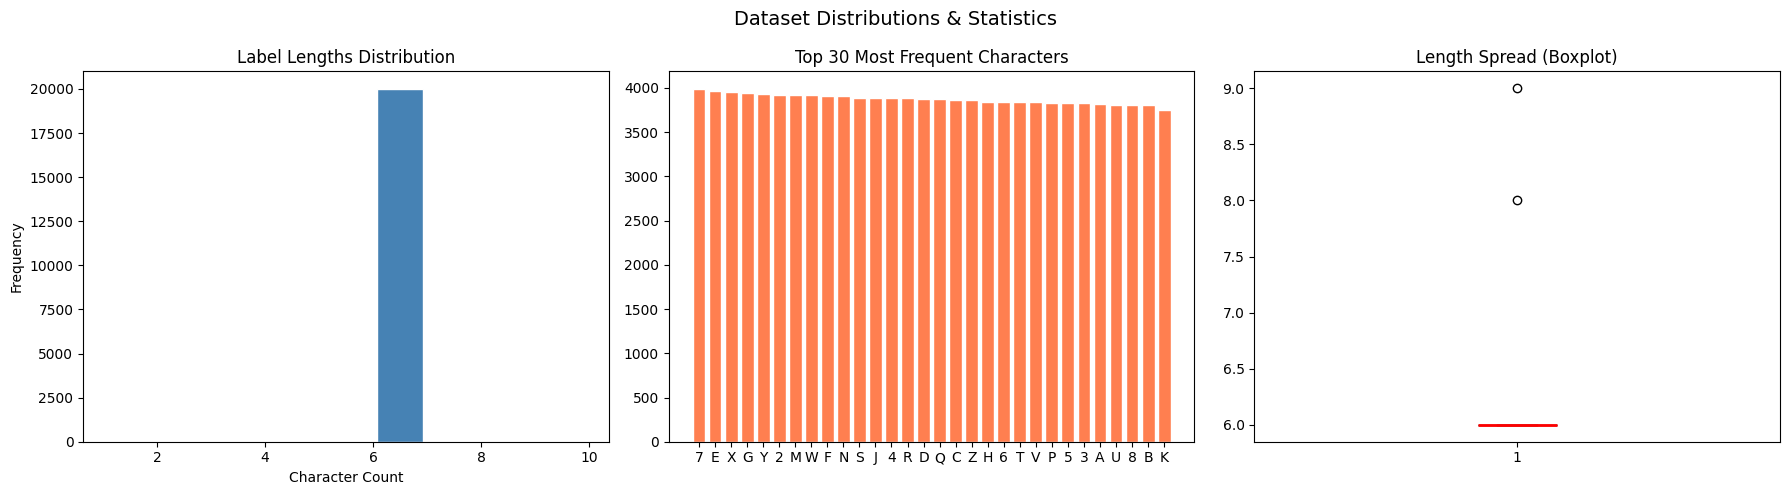

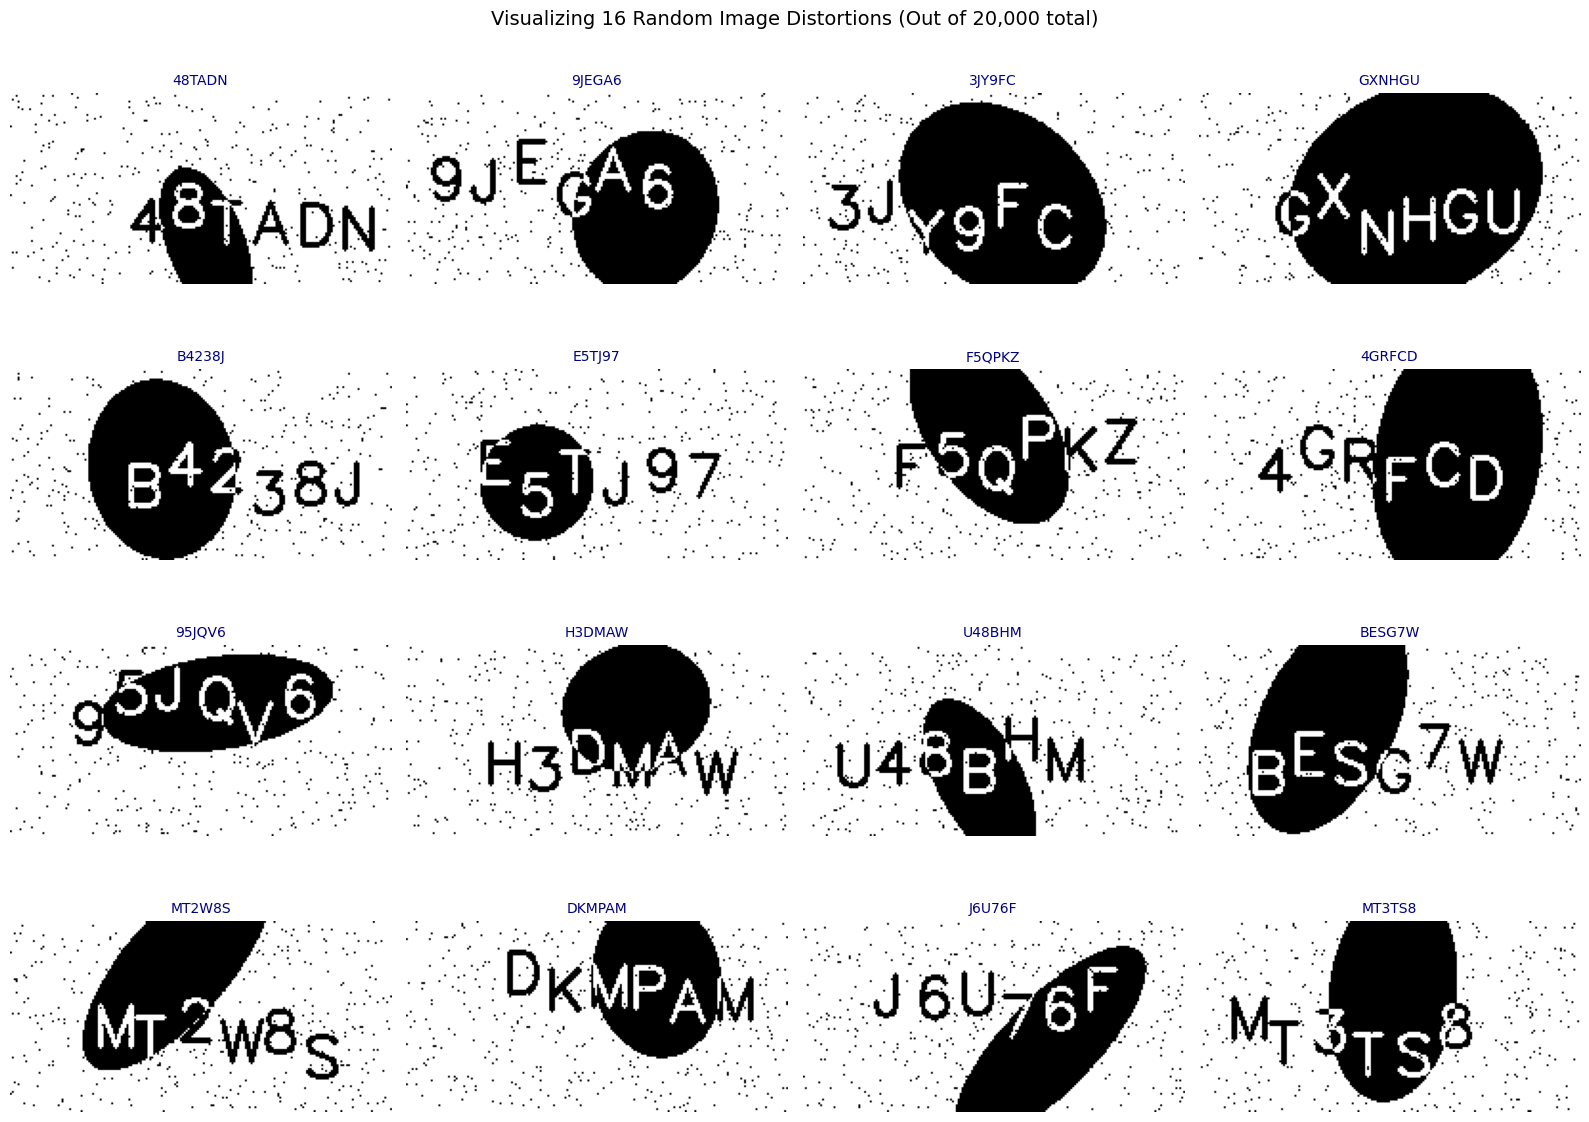

In [10]:
# Distribution Analysis
all_chars = ''.join(df_train['label'].tolist())
char_freq = Counter(all_chars)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Distributions & Statistics', fontsize=14)

axes[0].hist(df_train['label_len'], bins=range(1, df_train['label_len'].max()+2), color='steelblue', edgecolor='white', rwidth=0.85)
axes[0].set_title('Label Lengths Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

ch, fr = zip(*sorted(char_freq.items(), key=lambda x: -x[1])[:30])
axes[1].bar(ch, fr, color='coral', edgecolor='white')
axes[1].set_title('Top 30 Most Frequent Characters')

axes[2].boxplot(df_train['label_len'], patch_artist=True, boxprops=dict(facecolor='lightgreen'), medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Length Spread (Boxplot)')

plt.tight_layout()
plt.show()

# Visualizing 16 random training samples (Model will train on ALL 20,000 images)
sample = df_train.sample(min(16, len(df_train)), random_state=SEED)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle('Visualizing 16 Random Image Distortions (Out of 20,000 total)', fontsize=14)

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    loaded = False
    for ext in ['', '.png', '.jpg', '.jpeg']:
        p = os.path.join(TRAIN_IMG_DIR, str(row['image']) + ext)
        if os.path.exists(p):
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                ax.imshow(img, cmap='gray')
                ax.set_title(f"{row['label']}", fontsize=10, color='navy')
                loaded = True; break
    if not loaded:
        ax.set_title(f"Missing: {row['image']}", color='red', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Vocabulary and Hyperparameters

We strictly define a standard alphanumeric vocabulary. We also configure crucial parameters here like image height/width, learning rate, and batch size.

In [11]:
BLANK = '<B>'
alphanumeric_chars = '0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'
CHARS = [BLANK] + list(alphanumeric_chars)

CHAR2IDX = {c: i for i, c in enumerate(CHARS)}
IDX2CHAR = {i: c for i, c in enumerate(CHARS)}
NUM_CLASSES = len(CHARS)

class CFG:
    IMG_H        = 64
    IMG_W        = 256
    RNN_HIDDEN   = 256
    RNN_LAYERS   = 2
    DROPOUT      = 0.2
    EPOCHS       = 60
    PATIENCE     = 8     # Patience for Early Stopping based on CER
    BATCH_SIZE   = 32
    LR           = 1e-3
    WEIGHT_DECAY = 1e-4
    VAL_SPLIT    = 0.1
    NUM_WORKERS  = 0
    BLANK_IDX    = 0

## Preprocessing & Robust Augmentations

The images suffer from noise, occlusion, and shape deformation. We combat this using `Albumentations`. The `_preprocess` function is vital: we do **not** blindly resize images (which stretches and warps text unnaturally). Instead, we pad the aspect ratio using the median background value.

In [12]:
class DistortedTextDataset(Dataset):
    def __init__(self, df, img_dir, char2idx, img_h=CFG.IMG_H, img_w=CFG.IMG_W, augment=False, is_test=False):
        self.df       = df.reset_index(drop=True)
        self.img_dir  = img_dir
        self.char2idx = char2idx
        self.img_h    = img_h
        self.img_w    = img_w
        self.augment  = augment
        self.is_test  = is_test

        # Simulating challenge conditions: Noise, Blur, Deformation, Occlusion
        self.aug = A.Compose([
            A.OneOf([
                A.GaussNoise(var_limit=(10, 50), p=0.5),
                A.MultiplicativeNoise(multiplier=(0.8, 1.2), p=0.5)
            ], p=0.4),
            A.OneOf([
                A.MotionBlur(blur_limit=3, p=0.5),
                A.GaussianBlur(blur_limit=3, p=0.5),
            ], p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
            A.ElasticTransform(alpha=1, sigma=5, alpha_affine=5, p=0.2),
            A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.05, rotate_limit=3, border_mode=cv2.BORDER_REPLICATE, p=0.3),
            A.CoarseDropout(max_holes=3, max_height=8, max_width=8, min_holes=1, fill_value=0, p=0.3),
        ])

    def __len__(self):
        return len(self.df)

    def _load_img(self, fname):
        for ext in ['', '.png', '.jpg', '.jpeg']:
            p = os.path.join(self.img_dir, str(fname) + ext)
            if os.path.exists(p):
                img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
                if img is not None: return img
        
        raise FileNotFoundError(f"Could not find local image: {fname} in {self.img_dir}")

    def _preprocess(self, img):
        h, w = img.shape
        ratio = w / h
        new_w = int(self.img_h * ratio)
        if new_w > self.img_w: new_w = self.img_w
            
        img_resized = cv2.resize(img, (new_w, self.img_h), interpolation=cv2.INTER_LINEAR)
        padded_img = np.full((self.img_h, self.img_w), np.median(img), dtype=np.uint8)
        padded_img[:, :new_w] = img_resized

        img_normalized = padded_img.astype(np.float32) / 255.0
        return torch.tensor(img_normalized).unsqueeze(0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_img(row['image'])

        if self.augment and not self.is_test:
            img = self.aug(image=img)['image']

        img_tensor = self._preprocess(img)

        if self.is_test:
            return img_tensor, os.path.basename(str(row['image']))

        label = [self.char2idx.get(c) for c in str(row['label']) if c in self.char2idx]
        return img_tensor, torch.tensor(label, dtype=torch.long), len(label)

def collate_train(batch):
    imgs, lbls, lens = zip(*batch)
    imgs = torch.stack(imgs)
    lens = torch.tensor(lens, dtype=torch.long)
    lbls = torch.nn.utils.rnn.pad_sequence(lbls, batch_first=True, padding_value=0)
    return imgs, lbls, lens

def collate_test(batch):
    imgs, fnames = zip(*batch)
    return torch.stack(imgs), list(fnames)

df_tr, df_val = train_test_split(df_train, test_size=CFG.VAL_SPLIT, random_state=SEED, shuffle=True)
test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.lower().endswith(('.png','.jpg','.jpeg'))])
df_test = pd.DataFrame({'image': test_files})

train_ds = DistortedTextDataset(df_tr,   TRAIN_IMG_DIR, CHAR2IDX, augment=True)
val_ds   = DistortedTextDataset(df_val,  TRAIN_IMG_DIR, CHAR2IDX, augment=False)
test_ds  = DistortedTextDataset(df_test, TEST_IMG_DIR,  CHAR2IDX, augment=False, is_test=True)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=CFG.NUM_WORKERS, collate_fn=collate_train, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, collate_fn=collate_train, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, collate_fn=collate_test, pin_memory=True)

print(f'Train size: {len(df_tr)} | Val size: {len(df_val)} | Test size: {len(df_test)}')
imgs, lbls, lens = next(iter(train_loader))
print(f'Batch shape - Images: {imgs.shape}, Labels: {lbls.shape}')

Train size: 18000 | Val size: 2000 | Test size: 5000
Batch shape - Images: torch.Size([32, 1, 64, 256]), Labels: torch.Size([32, 6])


## Convolutional Recurrent Neural Network (CRNN)

The CNN backbone uses a VGG-like configuration. Once the feature maps are collapsed to a sequence, the BiLSTM layers learn the contextual relationships between neighboring characters.

In [13]:
class ConvBNReLU(nn.Module):
    def __init__(self, ic, oc, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ic, oc, k, stride=s, padding=p, bias=False),
            nn.BatchNorm2d(oc),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNReLU(1,   64),  ConvBNReLU(64,  64),  nn.MaxPool2d(2, 2),
            ConvBNReLU(64,  128), ConvBNReLU(128, 128), nn.MaxPool2d(2, 2),
            ConvBNReLU(128, 256), ConvBNReLU(256, 256), nn.Dropout2d(0.2),
            ConvBNReLU(256, 256), nn.MaxPool2d((2,1),(2,1)),
            ConvBNReLU(256, 512), ConvBNReLU(512, 512), nn.Dropout2d(0.2),
            ConvBNReLU(512, 512), nn.MaxPool2d((2,1),(2,1)),
            ConvBNReLU(512, 512, k=2, s=1, p=0),
        )
    def forward(self, x): return self.net(x)

class CRNN(nn.Module):
    def __init__(self, num_classes, hidden=CFG.RNN_HIDDEN, layers=CFG.RNN_LAYERS):
        super().__init__()
        self.cnn  = CNNBackbone()
        self.pool = nn.AdaptiveAvgPool2d((1, None))  
        self.rnn  = nn.LSTM(input_size=512, hidden_size=hidden, num_layers=layers,
                            bidirectional=True, batch_first=False,
                            dropout=CFG.DROPOUT if layers > 1 else 0)
        self.fc   = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        f = self.cnn(x)
        f = self.pool(f).squeeze(2)
        f = f.permute(2, 0, 1)
        out, _ = self.rnn(f)
        logits = self.fc(out)
        return F.log_softmax(logits, dim=2)

model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
print(f'Model initialized. Total learnable parameters: {sum(p.numel() for p in model.parameters()):,}')

Model initialized. Total learnable parameters: 11,872,639


## Rigorous Evaluation using CER

Here we define our optimization setup and the `compute_cer` function. We use a pure Python Levenshtein distance function across batches to strictly measure our primary metric (Character Error Rate) without needing external C++ build tools.

In [14]:
ctc_loss  = nn.CTCLoss(blank=CFG.BLANK_IDX, reduction='mean', zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = OneCycleLR(optimizer, max_lr=CFG.LR, steps_per_epoch=len(train_loader),
                       epochs=CFG.EPOCHS, pct_start=0.1, anneal_strategy='cos')

def greedy_decode(log_probs, idx2char, blank=CFG.BLANK_IDX):
    preds = log_probs.argmax(dim=2).cpu().numpy()
    results = []
    for b in range(preds.shape[1]):
        seq = preds[:, b].tolist()
        prev = None
        chars = []
        for c in seq:
            if c != prev:
                if c != blank: chars.append(idx2char.get(c, ''))
                prev = c
        results.append(''.join(chars))
    return results

# Pure Python Levenshtein Distance (to avoid C++ build errors)
def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

# THE CORE EVALUATION METRIC
def compute_cer(preds, targets):
    total_edit, total_chars = 0, 0
    for p, t in zip(preds, targets):
        total_edit  += levenshtein_distance(p, t)
        total_chars += max(len(t), 1)
    return total_edit / total_chars

def labels_to_str(labels, lengths, idx2char):
    result = []
    for i in range(labels.shape[0]):
        enc = labels[i, :lengths[i]].tolist()
        result.append(''.join([idx2char.get(c, '') for c in enc]))
    return result

def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss = 0.0
    for imgs, lbls, lens in loader:
        imgs, lbls, lens = imgs.to(device), lbls.to(device), lens.to(device)
        optimizer.zero_grad()
        log_probs = model(imgs)
        input_lengths = torch.full((imgs.size(0),), log_probs.size(0), dtype=torch.long, device=device)
        loss = loss_fn(log_probs, lbls, input_lengths, lens)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_tgts = [], []
    for imgs, lbls, lens in loader:
        log_probs = model(imgs.to(device))
        input_lengths = torch.full((imgs.size(0),), log_probs.size(0), dtype=torch.long, device=device)
        loss = loss_fn(log_probs, lbls.to(device), input_lengths, lens.to(device))
        total_loss += loss.item()
        all_preds.extend(greedy_decode(log_probs, IDX2CHAR))
        all_tgts.extend(labels_to_str(lbls.cpu(), lens.cpu(), IDX2CHAR))
    # Directly returning the actual CER score for validation
    return total_loss / len(loader), compute_cer(all_preds, all_tgts)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_cer):
        # The score is inverted CER so higher is better for tracking
        score = -val_cer
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

## Training Execution

We run the loop across our local epochs. Note that the best model is determined purely by the lowest validation CER achieved, ensuring our submission optimizes exactly for the challenge metric.

In [ ]:
history    = {'train_loss': [], 'val_loss': [], 'val_cer': []}
best_cer   = float('inf')
best_epoch = 0
CKPT       = 'best_local_crnn.pth'
early_stopper = EarlyStopping(patience=CFG.PATIENCE)

print(f'Starting local training on {DEVICE}...')
print(f'{"Epoch":>6} | {"Train Loss":>11} | {"Val Loss":>9} | {"CER":>7} | {"Time":>6} | Status')
print('-' * 65)

for ep in range(1, CFG.EPOCHS + 1):
    t0 = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, ctc_loss, DEVICE)
    val_loss, val_cer = validate(model, val_loader, ctc_loss, DEVICE)
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cer'].append(val_cer)

    flag = ''
    if val_cer < best_cer:
        best_cer   = val_cer
        best_epoch = ep
        torch.save(model.state_dict(), CKPT)
        flag = 'BEST CER'

    print(f'{ep:>6} | {train_loss:>11.4f} | {val_loss:>9.4f} | {val_cer:>7.4f} | {elapsed:>5.1f}s | {flag}')
    
    early_stopper(val_cer)
    if early_stopper.early_stop:
        print(f'\nEarly stopping triggered at epoch {ep}')
        break

print(f'\nBest CER: {best_cer:.4f} achieved at epoch {best_epoch}')

Starting local training on cuda...
 Epoch |  Train Loss |  Val Loss |     CER |   Time | Status
-----------------------------------------------------------------
     1 |      5.7291 |    3.7388 |  1.0000 | 236.0s | BEST CER
     2 |      3.6692 |    3.6228 |  0.9510 | 187.7s | BEST CER
     3 |      3.6210 |    3.6199 |  0.9542 | 188.0s | 
     4 |      3.6118 |    3.6181 |  0.9435 | 248.5s | BEST CER
     5 |      3.6102 |    3.6150 |  0.9730 | 265.5s | 
     6 |      3.6120 |    3.6163 |  0.9507 | 204.9s | 


## Convergence Curves

In [ ]:
ep_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Local Training Convergence', fontsize=14)

ax1.plot(ep_range, history['train_loss'], 'b-o', ms=3, lw=2, label='Train')
ax1.plot(ep_range, history['val_loss'],   'r-o', ms=3, lw=2, label='Val')
ax1.set_title('CTC Loss')
ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_range, history['val_cer'], 'g-o', ms=3, lw=2)
ax2.axhline(best_cer, color='red', ls='--', label=f'Best CER: {best_cer:.4f}')
ax2.set_title('Validation CER (Evaluation Metric)')
ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Validation Check

Visualizing some of the predictions produced by the best saved weights against the local ground truth.

In [ ]:
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.eval()

print(f'\n{"Prediction":<20} | {"Ground Truth":<20} | Match')
print('-' * 52)

with torch.no_grad():
    imgs, lbls, lens = next(iter(val_loader))
    preds   = greedy_decode(model(imgs.to(DEVICE)), IDX2CHAR)
    targets = labels_to_str(lbls, lens, IDX2CHAR)

correct = sum([1 for p, t in zip(preds[:20], targets[:20]) if p == t])
for p, t in zip(preds[:20], targets[:20]):
    print(f'{p:<20} | {t:<20} | {"YES" if p==t else "NO"}')

n = min(8, len(preds))
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Local Predictions vs Ground Truth', fontsize=13)
for i, ax in enumerate(axes.flatten()[:n]):
    ax.imshow(imgs[i, 0].numpy(), cmap='gray')
    col = 'green' if preds[i] == targets[i] else 'red'
    ax.set_title(f'P: {preds[i]}\nT: {targets[i]}', color=col, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Test Inference and Final Submission Export

We decode the unlabelled `test_images` directory and save them strictly in the required format: `submission_<name>_<enroll_no>.csv`.

In [ ]:
all_test_preds, all_test_files = [], []
with torch.no_grad():
    for imgs, fnames in test_loader:
        p = greedy_decode(model(imgs.to(DEVICE)), IDX2CHAR)
        all_test_preds.extend(p)
        all_test_files.extend(fnames)

print(f'Generated {len(all_test_preds)} local test predictions.')

NAME     = 'Tanisha Arya'
ENROLLNO = '24123044'

formatted_name = NAME.replace(' ', '_')
SUB_PATH = f'submission_{formatted_name}_{ENROLLNO}.csv'

df_sub   = pd.DataFrame({
    'image':      all_test_files,
    'prediction': all_test_preds
})
df_sub.to_csv(SUB_PATH, index=False)

print(f'Saved predictions locally to: {SUB_PATH}')
print(df_sub.head(10))